<a href="https://colab.research.google.com/github/Raijeku/quantum-eigengame/blob/main/EigenGame_quantum_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installs and imports

In [ ]:
!pip install pennylane
!pip install pennylane-qulacs["cpu"]
!pip install pyscf
#!pip install qiskit
!pip install qiskit-nature
#!pip install pennylane-qiskit
#!pip install qiskit-aer[torch] cuquantum

In [ ]:
import autograd.numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import qaoa
from pennylane import numpy as np
from scipy.linalg import expm, sqrtm, eigh
import networkx as nx
from jax import grad
import jax.numpy as jnp
import numpy
from tqdm import tqdm
import pickle

np.random.seed(0)

# Google drive

In [ ]:
import os
from datetime import date

today = str(date.today())

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

parent_dir = "/content/drive/My Drive/QuantumGame"

if not os.path.isdir(parent_dir):
  os.makedirs(parent_dir)

current_dir = f"/content/drive/My Drive/QuantumGame/{today}"

if not os.path.isdir(current_dir):
  os.makedirs(current_dir)

current_dir += '/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# $U1(\theta)$ ansatz gradient verification

In [ ]:
import jax.numpy as jnp

## 1 qubit at depth 1

In [ ]:
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2)
s /= np.linalg.norm(s)
Z, s

def U1(theta):
  return jnp.array([[1, 0], [0, jnp.exp(theta*1j)]])

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):
  return 2 * np.conjugate(s @ U1(theta)).T @ Z @ A(theta) @ s

print(U1(0))
print(circuit_U1(0))

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = 0. + 0j

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array(0.-0.99999994j, dtype=complex64, weak_type=True)

In [ ]:
grad_U1(theta)

Array(0.-0.99999994j, dtype=complex64)

## q qubit at depth 1

In [ ]:
qubits = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad = jnp.kron(grad, A(theta[i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(qubits) + 1j*np.zeros(qubits)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 5.7372224e-10+1.6650121e-08j,  5.7372224e-10+1.6650121e-08j,
       -1.7026657e-08+2.8641157e-08j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([ 5.8855354e-10+1.4901161e-08j,  5.8855354e-10+1.4901161e-08j,
       -3.0994556e-09+1.4901161e-08j], dtype=complex64)

## 1 qubit at depth p

In [ ]:
qubits = 1
depth = 3
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, depth):
    U1 = U1 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, depth):
    grad_inner_0 = grad_inner_0 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad = grad @ A(theta[i])
    for j in range(i+1, depth):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0]
 [ 0 -1]] [0.70710678 0.70710678]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(depth) + 1j*np.zeros(depth)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 4.6761670e-09-0.99999976j,  4.6761670e-09-0.99999976j,
       -2.5126155e-08-0.99999976j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([-4.3692885e-09-0.9999997j, -4.3692885e-09-0.9999997j,
       -4.3692885e-09-0.9999997j], dtype=complex64)

## q qubit at depth p

In [ ]:
qubits = 3
depth = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
  U1 = U1_0
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    U1 = U1 @ U1_i
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_l_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_l_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_row = []

  # depth 0 qubit 0
  grad_inner_0 = A(theta[0, 0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    grad_inner_0_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      grad_inner_0_i = jnp.kron(grad_inner_0_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    grad_inner_0 = grad_inner_0 @ grad_inner_0_i
  grad_inner_row.append(grad_inner_0)

  # depth 0 qubit i>0
  for i in range(1, qubits):
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    grad = jnp.kron(grad, A(theta[0, i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    for i in range(1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

  grad_inner.append(grad_inner_row)

  # depth p>0 qubit q
  for l in range(1, depth):
    grad_inner_row = []

    # depth p>0 qubit 0
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    for i in range(1, qubits):
      U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
    grad = U1_0
    for i in range(1, l):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i

    U1_l = A(theta[l, 0])
    for i in range(1, qubits):
      U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
    grad = grad @ U1_l

    for i in range(l+1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

    # depth p>0 qubit q>0
    for k in range(1, qubits):

      U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
      for i in range(1, qubits):
        U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
      grad = U1_0

      for i in range(1, l):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i

      U1_l = jnp.array([[1, 0], [0, jnp.exp(theta[l, 0]*1j)]])
      for i in range(1, k):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      U1_l = jnp.kron(U1_l, A(theta[l, k]))
      for i in range(k+1, qubits):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      grad = grad @ U1_l

      for i in range(l+1, depth):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i
      grad_inner_row.append(grad)

    grad_inner.append(grad_inner_row)

  return jnp.array([[2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i_j @ s for grad_i_j in grad_inner_i] for grad_inner_i in grad_inner ])

print(U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))
print(circuit_U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.zeros((depth, qubits)) + 1j*np.ones((depth, qubits))

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

# QuantumGame vs VQD

## Functions and setup

In [ ]:
def generate_pauli_string(qubits, terms=1):

  basis = ['X', 'Y', 'Z', 'I']

  pauli_list = []
  coeffs = numpy.random.rand(terms)
  for term in range(terms):
    pauli_list.append(''.join(numpy.random.choice(basis, size=qubits)))

  return pauli_list, coeffs

def term_to_pauli(pauli_term):
  Z = numpy.array([[1, 0], [0, -1]])
  X = numpy.array([[0, 1], [1, 0]])
  Y = numpy.array([[0, -1j], [1j, 0]])
  I = numpy.eye(2)

  match pauli_term:
      case 'X':
        return X
      case 'Y':
        return Y
      case 'Z':
        return Z
      case 'I':
        return I

def pauli_to_matrices(pauli_list):

  matrix_list = []
  for pauli_string in pauli_list:
    matrix = term_to_pauli(pauli_string[0])
    for pauli_term in pauli_string[1:]:
      matrix = numpy.kron(matrix, term_to_pauli(pauli_term))
    matrix_list.append(matrix)
  return matrix_list

def full_matrix(paulis, coeffs):
  matrix = numpy.zeros_like(paulis[0]).astype(complex)
  for i in range(len(coeffs)):
    matrix += coeffs[i]*paulis[i]

  return matrix

def pauli_to_gate(pauli_string, start_index=0):
  terms = list(pauli_string)
  term = terms[0]
  if term=='X':
      gates = qml.PauliX(start_index)
  elif term=='Y':
    gates = qml.PauliY(start_index)
  elif term=='Z':
    gates = qml.PauliZ(start_index)
  else:
    gates = qml.Identity(start_index)
  for i, term in enumerate(terms[1:]):
    if term=='X':
      gates = gates @ qml.PauliX(start_index+i+1)
    elif term=='Y':
      gates = gates @ qml.PauliY(start_index+i+1)
    elif term=='Z':
      gates = gates @ qml.PauliZ(start_index+i+1)
    else:
      gates = gates @ qml.Identity(start_index+i+1)
  return gates

pauli_list, coeffs = generate_pauli_string(3, terms=10)
print(pauli_list, coeffs)

matrices = pauli_to_matrices(pauli_list)
print(matrices)

['ZII', 'ZXY', 'YYY', 'XYX', 'IXI', 'YZI', 'IXZ', 'IXY', 'IYI', 'IZI'] [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773   0.96366276 0.38344152]
[array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1., -0., -0., -0.],
       [ 0.,  0.,  0.,  0., -0., -1., -0., -0.],
       [ 0.,  0.,  0.,  0., -0., -0., -1., -0.],
       [ 0.,  0.,  0.,  0., -0., -0., -0., -1.]]), array([[ 0.+0.j,  0.-0.j,  0.+0.j,  0.-1.j,  0.+0.j,  0.-0.j,  0.+0.j,
         0.-0.j],
       [ 0.+0.j,  0.+0.j,  0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.-1.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j,  0.+0.j,
         0.-0.j],
       [ 0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j, -0.

In [ ]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

problem = driver.run()
hamiltonian = problem.hamiltonian.second_q_op()
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_op = mapper.map(hamiltonian)

pauli_list = []
coeffs = []
for pauli, coeff in sorted(qubit_op.label_iter()):
    print(f"{coeff.real:+.8f} * {pauli}")
    pauli_list.append(pauli)
    coeffs.append(-coeff.real)

-1.05237325 * II
+0.39793742 * IZ
+0.18093120 * XX
-0.39793742 * ZI
-0.01128010 * ZZ


In [ ]:
qubits = 2
dim = 2**qubits
#pauli_list, coeffs = generate_pauli_string(qubits, terms=10)
pauli_gates = [pauli_to_gate(pauli_str) for pauli_str in pauli_list]
pauli_gatesh = [pauli_to_gate(pauli_str, start_index=1) for pauli_str in pauli_list]
print(pauli_list)
print(pauli_gates)
print(pauli_gatesh)
matrices = pauli_to_matrices(pauli_list)
matrix = full_matrix(matrices, coeffs)
print(np.linalg.eigvalsh(matrix))

['II', 'IZ', 'XX', 'ZI', 'ZZ']
[I(0) @ I(1), I(0) @ Z(1), X(0) @ X(1), Z(0) @ I(1), Z(0) @ Z(1)]
[I(1) @ I(2), I(1) @ Z(2), X(1) @ X(2), Z(1) @ I(2), Z(1) @ Z(2)]
[0.22491125 0.88272215 1.24458455 1.85727503]


## Exact eigenvalues

In [ ]:
exact_eigvals = sorted(np.linalg.eigvalsh(matrix), reverse=True)
data = {
    'exact_eigvals': exact_eigvals
}
file = open(current_dir + 'exact.pkl', 'wb')
pickle.dump(data, file)
file.close()

exact_eigvals

[tensor(1.85727503, requires_grad=True),
 tensor(1.24458455, requires_grad=True),
 tensor(0.88272215, requires_grad=True),
 tensor(0.22491125, requires_grad=True)]

## QuantumGame noiseless experiment

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)
from functools import partial

def quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params)

  @qml.compile
  @qml.qnode(dev, diff_method="adjoint")
  def cost_function_vqe(params, M):
      circuit_vqe(params)
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  @qml.compile
  @qml.qnode(devh, diff_method="parameter-shift")
  def hadamard_test_real(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  @qml.compile
  @qml.qnode(devh, diff_method="parameter-shift")
  def hadamard_test_imag(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.S(0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  def hadamard_test(params_a, params_b, pauli):
    return hadamard_test_real(params_a, params_b, pauli) + 1j*hadamard_test_imag(params_a, params_b, pauli)

  def hadamard_test_sum(params, paulis, coeffs, j):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
    res = hadamard_test(params, params_vec[j], pauli_combination)
    return res

  def cost_function_vqe_sum(params, paulis, coeffs):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
      pauli_combination -= paulis[i]*coeffs[i]
    res = cost_function_vqe(params, pauli_combination)
    return res

  def cost_function_sum(params, paulis, paulish, coeffs):
    sum = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
    for j in range(k):
      sum -= np.abs(hadamard_test_sum(params, paulish, coeffs, j))**2/eigenvalues[j]
    return sum

  k=0
  params_vec = []
  eigenvalues = []

  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      #grad, cost = optimizer.compute_grad(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      #params = optimizer.apply_grad(grad, params)
      params, cost = optimizer.step_and_cost(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(cost_function_vqe_sum)(params, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        #grad, cost = optimizer.compute_grad(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        #params = optimizer.apply_grad(grad, params)
        params, cost = optimizer.step_and_cost(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        grad = qml.grad(cost_function_sum)(params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps


eigenvalues, params_vec, costs_vec, steps_vec = quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.AdamOptimizer(stepsize=0.01), max_steps=500, layers=3, params_layer=3, shots=None)

Iteration 288, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0097:  57%|█████▋    | 287/500 [00:12<00:09, 22.11it/s]
Iteration 86, Cost: 1.2445, Rewards: 1.2445, Penalties: -0.0000, Gradient norm: 0.0090:  17%|█▋        | 85/500 [07:39<37:23,  5.41s/it]
Iteration 219, Cost: 0.8826, Rewards: 0.8828, Penalties: -0.0002, Gradient norm: 0.0100:  44%|████▎     | 218/500 [36:56<47:47, 10.17s/it]
Iteration 122, Cost: 0.2241, Rewards: 0.2314, Penalties: -0.0073, Gradient norm: 0.0098:  24%|██▍       | 121/500 [29:54<1:33:40, 14.83s/it]


In [ ]:
data = {
    'eigenvalues': eigenvalues,
    'params_vec': params_vec,
    'costs_vec': costs_vec,
    'steps_vec': steps_vec
}
file = open(current_dir + 'quantumgame_noiseless.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'quantumgame_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues = data['eigenvalues']
params_vec = data['params_vec']
costs_vec = data['costs_vec']
steps_vec = data['steps_vec']

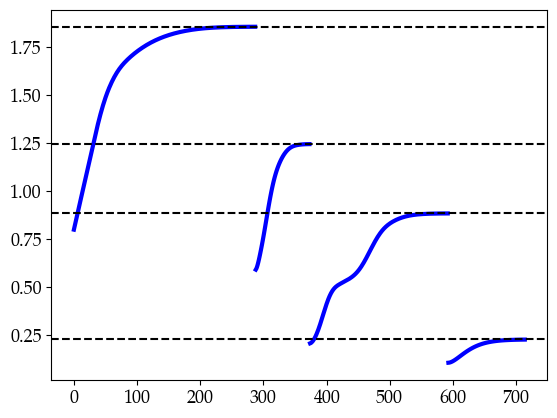

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']

plt.plot([i for i in range(steps_vec[0])], costs_vec[0], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0], steps_vec[0] + steps_vec[1])], costs_vec[1], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0] + steps_vec[1], steps_vec[0] + steps_vec[1] + steps_vec[2])], costs_vec[2], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0] + steps_vec[1] + steps_vec[2], steps_vec[0] + steps_vec[1] + steps_vec[2] + steps_vec[3])], costs_vec[3], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## QuantumGame 10k shots experiment

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)
from functools import partial

def quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params)

  @qml.compile
  @qml.qnode(dev)
  def cost_function_vqe(params, M):
      circuit_vqe(params)
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  @qml.compile
  @qml.qnode(devh)
  def hadamard_test_real(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  @qml.compile
  @qml.qnode(devh)
  def hadamard_test_imag(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.S(0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  def hadamard_test(params_a, params_b, pauli):
    return hadamard_test_real(params_a, params_b, pauli) + 1j*hadamard_test_imag(params_a, params_b, pauli)

  def hadamard_test_sum(params, paulis, coeffs, j):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
    res = hadamard_test(params, params_vec[j], pauli_combination)
    return res

  def cost_function_vqe_sum(params, paulis, coeffs):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
      pauli_combination -= paulis[i]*coeffs[i]
    res = cost_function_vqe(params, pauli_combination)
    return res

  def cost_function_sum(params, paulis, paulish, coeffs):
    sum = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
    for j in range(k):
      sum -= np.abs(hadamard_test_sum(params, paulish, coeffs, j))**2/eigenvalues[j]
    return sum

  k=0
  params_vec = []
  eigenvalues = []

  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      #grad, cost = optimizer.compute_grad(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      #params = optimizer.apply_grad(grad, params)
      params, cost = optimizer.step_and_cost(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(cost_function_vqe_sum)(params, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        #grad, cost = optimizer.compute_grad(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        #params = optimizer.apply_grad(grad, params)
        params, cost = optimizer.step_and_cost(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        grad = qml.grad(cost_function_sum)(params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

eigenvalues_10k, params_vec_10k, costs_vec_10k, steps_vec_10k = quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.AdamOptimizer(stepsize=0.01), max_steps=500, layers=3, params_layer=3, shots=10000)

Iteration 285, Cost: 1.8587, Rewards: 1.8587, Penalties: 0.0000, Gradient norm: 0.0093:  57%|█████▋    | 284/500 [01:20<01:00,  3.55it/s]
Iteration 176, Cost: 1.2446, Rewards: 1.2444, Penalties: 0.0002, Gradient norm: 0.0095:  35%|███▌      | 175/500 [13:52<25:45,  4.75s/it]
Iteration 215, Cost: 0.8824, Rewards: 0.8829, Penalties: -0.0005, Gradient norm: 0.0087:  43%|████▎     | 214/500 [32:27<43:22,  9.10s/it]
Iteration 283, Cost: 0.2225, Rewards: 0.2251, Penalties: -0.0026, Gradient norm: 0.0095:  56%|█████▋    | 282/500 [1:04:08<49:35, 13.65s/it]


In [ ]:
data = {
    'eigenvalues_10k': eigenvalues_10k,
    'params_vec_10k': params_vec_10k,
    'costs_vec_10k': costs_vec_10k,
    'steps_vec_10k': steps_vec_10k
}
file = open(current_dir + 'quantumgame_10k.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'quantumgame_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues_10k = data['eigenvalues_10k']
params_vec_10k = data['params_vec_10k']
costs_vec_10k = data['costs_vec_10k']
steps_vec_10k = data['steps_vec_10k']

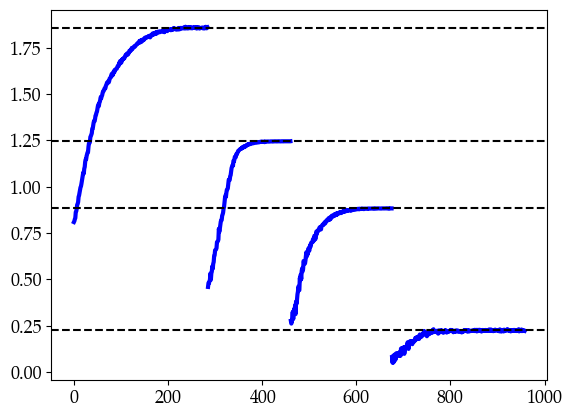

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']

plt.plot([i for i in range(steps_vec_10k[0])], costs_vec_10k[0], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0], steps_vec_10k[0] + steps_vec_10k[1])], costs_vec_10k[1], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0] + steps_vec_10k[1], steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2])], costs_vec_10k[2], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2], steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2] + steps_vec_10k[3])], costs_vec_10k[3], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## VQD noiseless experiment

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=3, params_layer=3, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device('default.qubit', wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh, diff_method="adjoint")
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev, diff_method="adjoint")
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  k=0
  params_vec = []
  eigenvalues = []

  beta = 0.8
  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  betas = [beta]*n_eigs
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
    steps.append(max_steps)

  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

qubits = 2
dim = 2**qubits
#pauli_list, coeffs = generate_pauli_string(qubits, terms=10)
pauli_gates = [pauli_to_gate(pauli_str) for pauli_str in pauli_list]
print(pauli_list)
print(pauli_gates)
matrices = pauli_to_matrices(pauli_list)
matrix = full_matrix(matrices, coeffs)
print(np.linalg.eigvalsh(matrix))

vqd_eigenvalues, vqd_params_vec, vqd_costs_vec, vqd_steps_vec = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.AdamOptimizer(stepsize=0.01), max_steps=500, layers=3, params_layer=3)

['II', 'IZ', 'XX', 'ZI', 'ZZ']
[I(0) @ I(1), I(0) @ Z(1), X(0) @ X(1), Z(0) @ I(1), Z(0) @ Z(1)]
[0.22491125 0.88272215 1.24458455 1.85727503]


Iteration 245, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0099:  49%|████▉     | 244/500 [00:14<00:15, 16.80it/s]
Iteration 142, Cost: 1.2444, Rewards: 1.2445, Penalties: -0.0001, Gradient norm: 0.0099:  28%|██▊       | 141/500 [00:23<00:59,  6.01it/s]
Iteration 250, Cost: 1.0571, Rewards: 1.8570, Penalties: -0.7998, Gradient norm: 0.0099:  50%|████▉     | 249/500 [01:11<01:11,  3.50it/s]
Iteration 117, Cost: 0.8827, Rewards: 0.8840, Penalties: -0.0013, Gradient norm: 0.0097:  23%|██▎       | 116/500 [00:41<02:18,  2.77it/s]


In [ ]:
data = {
    'vqd_eigenvalues': vqd_eigenvalues,
    'vqd_params_vec': vqd_params_vec,
    'vqd_costs_vec': vqd_costs_vec,
    'vqd_steps_vec': vqd_steps_vec
}
file = open(current_dir + 'vqd_noiseless.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'vqd_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues = data['vqd_eigenvalues']
vqd_params_vec = data['vqd_params_vec']
vqd_costs_vec = data['vqd_costs_vec']
vqd_steps_vec = data['vqd_steps_vec']

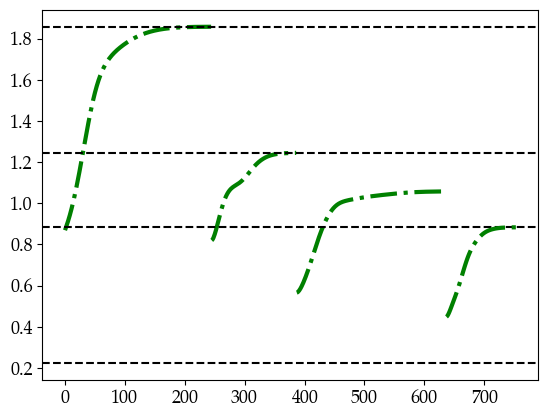

In [ ]:
plt.plot([i for i in range(vqd_steps_vec[0])], vqd_costs_vec[0], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0], vqd_steps_vec[0] + vqd_steps_vec[1])], vqd_costs_vec[1], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0] + vqd_steps_vec[1], vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2])], vqd_costs_vec[2], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2], vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2] + vqd_steps_vec[3])], vqd_costs_vec[3], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## VQD 10k shots experiment

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=10000):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh)
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev)
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  k=0
  params_vec = []
  eigenvalues = []

  beta = 0.8
  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  betas = [beta]*n_eigs
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

vqd_eigenvalues_10k, vqd_params_vec_10k, vqd_costs_vec_10k, vqd_steps_vec_10k = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.AdamOptimizer(stepsize=0.01), max_steps=500, layers=3, params_layer=3, shots=10000)

Iteration 266, Cost: 1.8580, Rewards: 1.8580, Penalties: 0.0000, Gradient norm: 0.0078:  53%|█████▎    | 265/500 [01:20<01:11,  3.30it/s]
Iteration 105, Cost: 1.2417, Rewards: 1.2447, Penalties: -0.0030, Gradient norm: 0.0099:  21%|██        | 104/500 [00:59<03:47,  1.74it/s]
Iteration 65, Cost: 0.8853, Rewards: 0.8853, Penalties: -0.0000, Gradient norm: 0.0090:  13%|█▎        | 64/500 [00:49<05:37,  1.29it/s]
Iteration 500, Cost: 1.0661, Rewards: 1.8578, Penalties: -0.7918, Gradient norm: 0.0236: 100%|██████████| 500/500 [07:55<00:00,  1.05it/s]


In [ ]:
data = {
    'vqd_eigenvalues_10k': vqd_eigenvalues_10k,
    'vqd_params_vec_10k': vqd_params_vec_10k,
    'vqd_costs_vec_10k': vqd_costs_vec_10k,
    'vqd_steps_vec_10k': vqd_steps_vec_10k
}
file = open(current_dir + 'vqd_10k.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'vqd_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues_10k = data['vqd_eigenvalues_10k']
vqd_params_vec_10k = data['vqd_params_vec_10k']
vqd_costs_vec_10k = data['vqd_costs_vec_10k']
vqd_steps_vec_10k = data['vqd_steps_vec_10k']

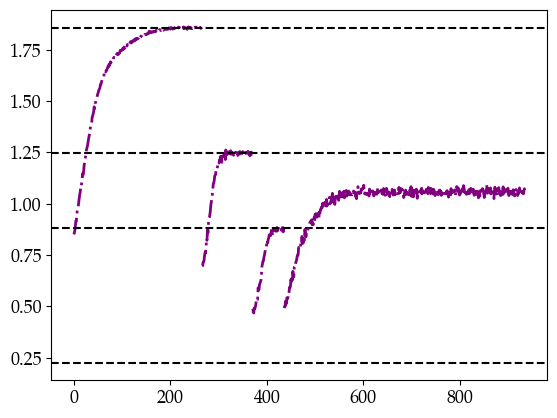

In [ ]:
plt.plot([i for i in range(vqd_steps_vec_10k[0])], vqd_costs_vec_10k[0], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1])], vqd_costs_vec_10k[1], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2])], vqd_costs_vec_10k[2], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2] + vqd_steps_vec_10k[3])], vqd_costs_vec_10k[3], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## Recover data

In [ ]:
file = open(current_dir + 'exact.pkl', 'rb')
data = pickle.load(file)
file.close()

exact_eigvals = data['exact_eigvals']

file = open(current_dir + 'quantumgame_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues = data['eigenvalues']
params_vec = data['params_vec']
costs_vec = data['costs_vec']
steps_vec = data['steps_vec']

file = open(current_dir + 'quantumgame_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

fake_eigenvalues = data['eigenvalues_10k']
fake_params_vec = data['params_vec_10k']
fake_costs_vec = data['costs_vec_10k']
fake_steps_vec = data['steps_vec_10k']

file = open(current_dir + 'vqd_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues = data['vqd_eigenvalues']
vqd_params_vec = data['vqd_params_vec']
vqd_costs_vec = data['vqd_costs_vec']
vqd_steps_vec = data['vqd_steps_vec']

file = open(current_dir + 'vqd_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

fake_vqd_eigenvalues = data['vqd_eigenvalues_10k']
fake_vqd_params_vec = data['vqd_params_vec_10k']
fake_vqd_costs_vec = data['vqd_costs_vec_10k']
fake_vqd_steps_vec = data['vqd_steps_vec_10k']

## Plots

In [ ]:
import shutil

# Move the uploaded font file to the system fonts directory
shutil.move('Palatino.ttf', '/usr/share/fonts/truetype/Palatino.ttf')

font_cache_path = os.path.expanduser('~/.cache/matplotlib')
shutil.rmtree(font_cache_path, ignore_errors=True)

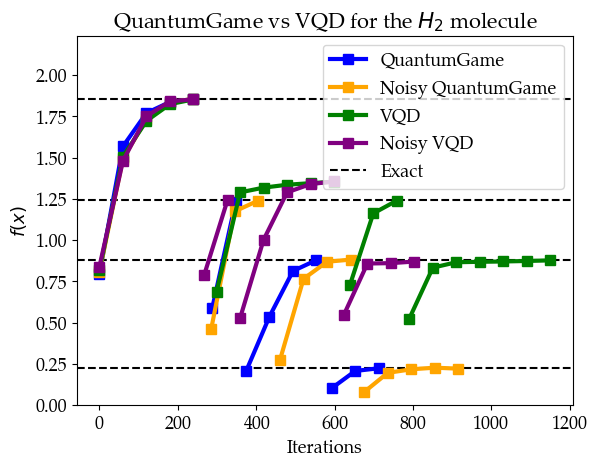

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']
granularity = 60
markers = ['s', 's', 's', 's']
markersize = 7.5
linewidth = 3

def range_func(vec, granularity):
  if len(vec)>=granularity:
    new_vec = vec[::granularity]
    #new_vec = vec[len(vec)::-granularity][::-1]
  else:
    new_vec = [vec[0], vec[-1]]

  return new_vec

costs_vec_granular = [range_func(costs_vec[i], granularity) for i in range(len(costs_vec))]
fake_costs_vec_granular = [range_func(fake_costs_vec[i], granularity) for i in range(len(costs_vec))]
vqd_costs_vec_granular = [range_func(vqd_costs_vec[i], granularity) for i in range(len(costs_vec))]
fake_vqd_costs_vec_granular = [range_func(fake_vqd_costs_vec[i], granularity) for i in range(len(costs_vec))]

plt.rcParams["font.family"] = "Palatino"
plt.rcParams["font.size"] = 13
plt.title(r'QuantumGame vs VQD for the $H_2$ molecule')
plt.xlabel('Iterations')
plt.ylabel(r'$f(x)$')

plt.plot([], linestyle='-', label='QuantumGame', color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy QuantumGame', color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot([], linestyle='-', label='VQD', color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy VQD', color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.plot([], linestyle='--', label='Exact', color='black')

plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.axhline(exact_eigvals[3], linestyle='--', color='black')

plt.plot(range_func([i for i in range(0, steps_vec[0])], granularity), costs_vec_granular[0], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(0, fake_steps_vec[0])], granularity), fake_costs_vec_granular[0], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(0, vqd_steps_vec[0])], granularity), vqd_costs_vec_granular[0], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(0, fake_vqd_steps_vec[0])], granularity), fake_vqd_costs_vec_granular[0], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(steps_vec[0], sum(steps_vec[:2]))], granularity), costs_vec_granular[1], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(fake_steps_vec[0], sum(fake_steps_vec[:2]))], granularity), fake_costs_vec_granular[1], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(vqd_steps_vec[0], sum(vqd_steps_vec[:2]))], granularity), vqd_costs_vec_granular[1], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(fake_vqd_steps_vec[0], sum(fake_vqd_steps_vec[:2]))], granularity), fake_vqd_costs_vec_granular[1], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:2]), sum(steps_vec[:3]))], granularity), costs_vec_granular[2], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(fake_steps_vec[:2]), sum(fake_steps_vec[:3]))], granularity), fake_costs_vec_granular[2], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:2]), sum(vqd_steps_vec[:3]))], granularity), vqd_costs_vec_granular[2], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(fake_vqd_steps_vec[:2]), sum(fake_vqd_steps_vec[:3]))], granularity), fake_vqd_costs_vec_granular[2], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:3]), sum(steps_vec[:4]))], granularity), costs_vec_granular[3], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(fake_steps_vec[:3]), sum(fake_steps_vec[:4]))], granularity), fake_costs_vec_granular[3], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:3]), sum(vqd_steps_vec[:4]))], granularity), vqd_costs_vec_granular[3], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(fake_vqd_steps_vec[:3]), sum(fake_vqd_steps_vec[:4]))], granularity), fake_vqd_costs_vec_granular[3], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.ylim([0, 2.24])
plt.legend();

plt.savefig(current_dir + 'quantumgame_vqd.pdf', bbox_inches='tight')
plt.savefig(current_dir + 'quantumgame_vqd.png', bbox_inches='tight')